# Ejercicio 1.
Genera una imagen semejante a una diana de tiro al blanco como se aprecia en la imagen a continuación
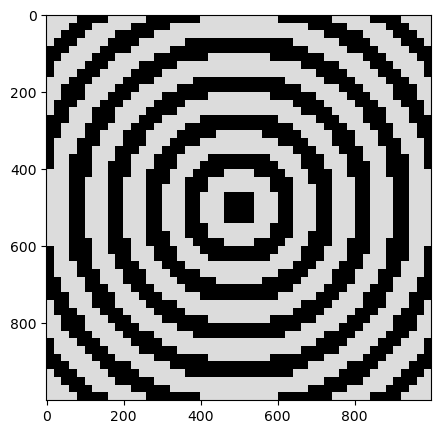


# Ejercicio 2.
Genera la imagen tal cual se muestra acontinuación, tomar en cuenta el tamaño 
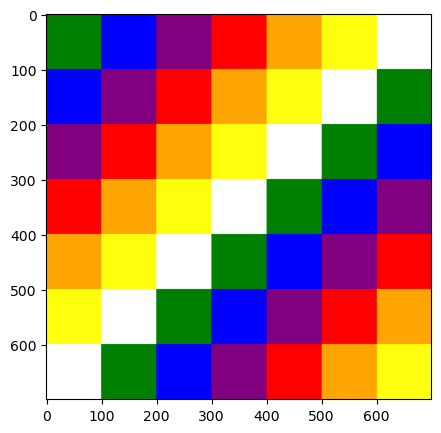

✅ Tablero guardado en: clases/img/img_ejercicio_3\tablero_ajedrez.png


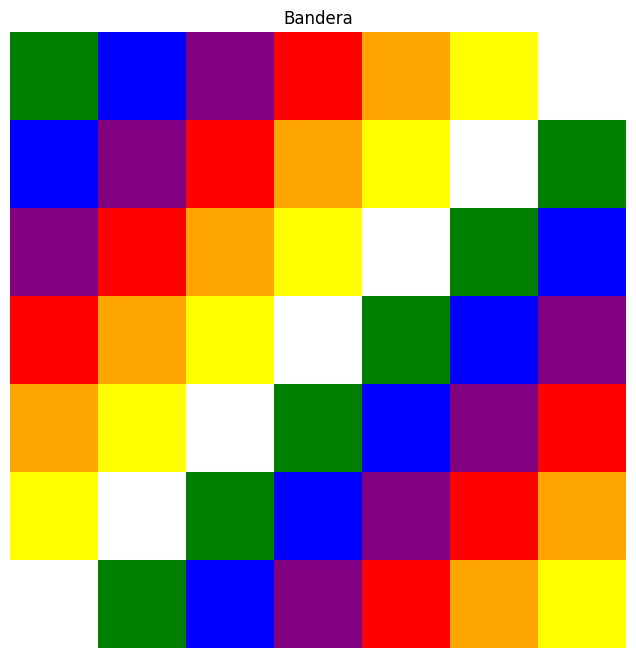

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os # <-- CAMBIO 1: Importamos os para manejar directorios de forma segura

# --- CONFIGURACIÓN DE RUTAS ---
# CAMBIO 2: Ajustamos a la carpeta base de tu proyecto en VS Code
carpeta_base = 'clases/img/'
# CAMBIO 3: Definimos la subcarpeta específica para este ejercicio
carpeta_ejercicio = os.path.join(carpeta_base, 'img_ejercicio_3')

# CAMBIO 4: Si la carpeta no existe, la creamos para que plt.imsave no de error
if not os.path.exists(carpeta_ejercicio):
    os.makedirs(carpeta_ejercicio)
    print(f"✅ Carpeta creada con éxito: {carpeta_ejercicio}")

# --- PARÁMETROS DEL TABLERO ---
tamanio_casilla = 100
numero_casillas = 7
tamanio_imagen = tamanio_casilla * numero_casillas

# Creamos lienzo negro (3 canales para RGB)
imagen_ajedrez = np.zeros((tamanio_imagen, tamanio_imagen, 3), dtype=np.uint8)

# --- DEFINIR PALETA DE COLORES (estilo arcoíris) ---
# Sigue la imagen de ejemplo: cada fila desplaza la paleta una casilla
paleta_base = [
    [0, 128, 0],      # Verde oscuro
    [0, 0, 255],      # Azul
    [128, 0, 128],    # Púrpura
    [255, 0, 0],      # Rojo
    [255, 165, 0],    # Naranja
    [255, 255, 0],    # Amarillo
    [255, 255, 255],  # Blanco
]

# --- ASIGNAR COLORES AL TABLERO ---
for fila in range(numero_casillas):
    for columna in range(numero_casillas):
        index = (columna + fila) % len(paleta_base)
        color = paleta_base[index]

        inicio_fila = fila * tamanio_casilla
        fin_fila = inicio_fila + tamanio_casilla
        inicio_columna = columna * tamanio_casilla
        fin_columna = inicio_columna + tamanio_casilla

        imagen_ajedrez[inicio_fila:fin_fila, inicio_columna:fin_columna] = color

# --- GUARDAR IMAGEN ---
ruta_guardado = os.path.join(carpeta_ejercicio, "tablero_ajedrez.png")
plt.imsave(ruta_guardado, imagen_ajedrez)
print(f"✅ Tablero guardado en: {ruta_guardado}")

# --- MOSTRAR IMAGEN ---
plt.figure(figsize=(8, 8))  # Tamaño original solicitado
plt.imshow(imagen_ajedrez)
plt.title("Bandera")
plt.axis('off')
plt.show()

# Ejercicio 3.
Tomando en cuenta la imagen1.jpg elige un punto de interés al azar (funcion randomica), solariza y posteriza la imagen, realiza un tratamiento de umbralización(el de preferencia), mezcla tecnicas y obtiene un filtro artistico,lista todas las imágenes con sus correspondientes titulos, guarda todas las imágenes resultantes con sus nombres.

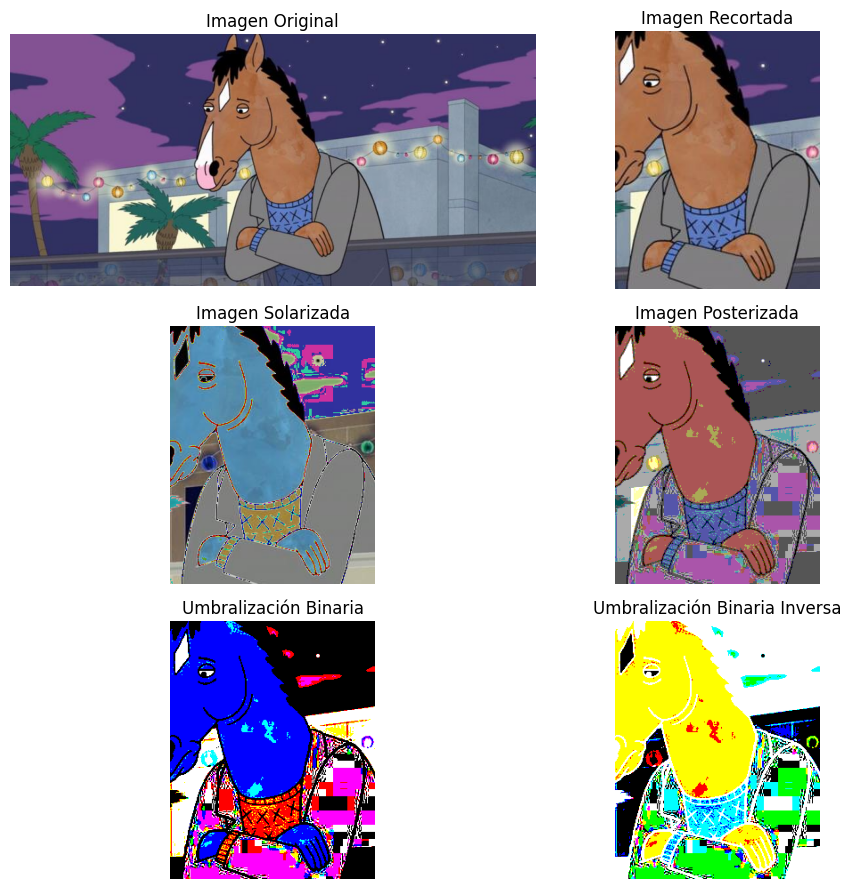

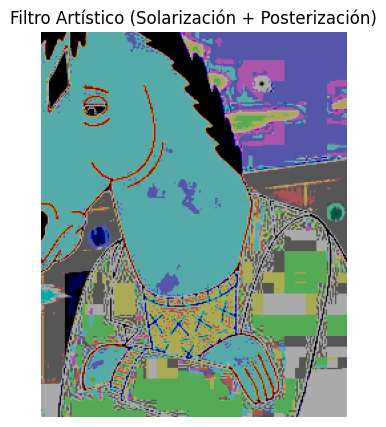

✅ Todas las imágenes guardadas en: clases/img/img_ejercicio_3_resultados


In [25]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt
import os

# Define the base folder path as used in other cells
carpeta_base = 'clases/img/'

img = cv2.imread(os.path.join(carpeta_base, 'imagen1.jpg'))

def recortar_imagen_random(img, x, y, height, width):
    x_random = np.random.randint(0, img.shape[1] - width)
    y_random = np.random.randint(0, img.shape[0] - height)
    return img[y_random:y_random + height, x_random:x_random + width]
img_recortada = recortar_imagen_random(img, 0, 0, 290, 230)
#cv2.imwrite('lena_recortada.png', img_recortada) 


def solarizar(img_recortada, umbral):
    # APLICAMOS SOLARIZACION A LA IMAGEN
    imagen_sol = np.where(img_recortada < umbral, img_recortada, 255 - img_recortada)
    return imagen_sol

umbral = 50  # Definir el umbral para la solarización
img_fin_sol=solarizar(img_recortada, umbral)  # Aplicar la función de solarización


def posterizar(img_recortada, niveles):
    # APLICAMOS POSTERIZACION A LA IMAGEN
    factor_escala = 256 // niveles
    imagen_post = np.round(img_recortada / factor_escala) * factor_escala
    return imagen_post.astype(np.uint8) # Convertir a uint8 para mantener el formato de imagen

nvles = 3  # Definir el número de niveles para la posterización
img_fin_pos=posterizar(img_recortada, nvles)  # Aplicar la función de posterización

# umbralización binaria
_, umbral_binario = cv2.threshold(img_recortada, 127, 255, cv2.THRESH_BINARY)

# umbralización binaria inversa
_, umbral_binario_in = cv2.threshold(img_recortada, 127, 255, cv2.THRESH_BINARY_INV)

# Create output folder for saving images
carpeta_salida = os.path.join(carpeta_base, 'img_ejercicio_3_resultados')
if not os.path.exists(carpeta_salida):
    os.makedirs(carpeta_salida)

# Save original image
cv2.imwrite(os.path.join(carpeta_salida, 'imagen_original.jpg'), img)

# Save cropped image
cv2.imwrite(os.path.join(carpeta_salida, 'imagen_recortada.jpg'), img_recortada)

# Save solarized image (convert to BGR for saving)
cv2.imwrite(os.path.join(carpeta_salida, 'imagen_solarizada.jpg'), cv2.cvtColor(img_fin_sol.astype(np.uint8), cv2.COLOR_RGB2BGR))

# Save posterized image
cv2.imwrite(os.path.join(carpeta_salida, 'imagen_posterizada.jpg'), cv2.cvtColor(img_fin_pos, cv2.COLOR_RGB2BGR))

# Save binary threshold image
cv2.imwrite(os.path.join(carpeta_salida, 'umbralizacion_binaria.jpg'), umbral_binario)

# Save inverse binary threshold image
cv2.imwrite(os.path.join(carpeta_salida, 'umbralizacion_binaria_inversa.jpg'), umbral_binario_in)

# Create an artistic filter by combining solarization and posterization
img_artistica = posterizar(solarizar(img_recortada, umbral), nvles)
cv2.imwrite(os.path.join(carpeta_salida, 'filtro_artistico.jpg'), cv2.cvtColor(img_artistica, cv2.COLOR_RGB2BGR))

plt.figure(figsize=(10, 9))

plt.subplot(3, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(3, 2, 2)
plt.imshow(cv2.cvtColor(img_recortada, cv2.COLOR_BGR2RGB))  
plt.title('Imagen Recortada')
plt.axis('off')

plt.subplot(3, 2, 3)
plt.imshow(cv2.cvtColor(img_fin_sol.astype(np.uint8), cv2.COLOR_BGR2RGB))
plt.title('Imagen Solarizada')
plt.axis('off')

plt.subplot(3, 2, 4)
plt.imshow(cv2.cvtColor(img_fin_pos, cv2.COLOR_BGR2RGB))
plt.title('Imagen Posterizada')
plt.axis('off')

plt.subplot(3, 2, 5)
plt.imshow(umbral_binario, cmap='gray')
plt.title('Umbralización Binaria')
plt.axis('off')

plt.subplot(3, 2, 6)
plt.imshow(umbral_binario_in, cmap='gray')
plt.title('Umbralización Binaria Inversa')
plt.axis('off')

plt.tight_layout()
plt.show()

# Additional display for artistic filter
plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(img_artistica, cv2.COLOR_BGR2RGB))
plt.title('Filtro Artístico (Solarización + Posterización)')
plt.axis('off')
plt.show()

print(f"✅ Todas las imágenes guardadas en: {carpeta_salida}")
plt.show()

# Ejercicio 4.
Genera un avatar, basandote en una imagen tuya que usaste en practicas anteriores, este avatar debe tener filtros y/o umbralizaciones.
Guarda la imagen 

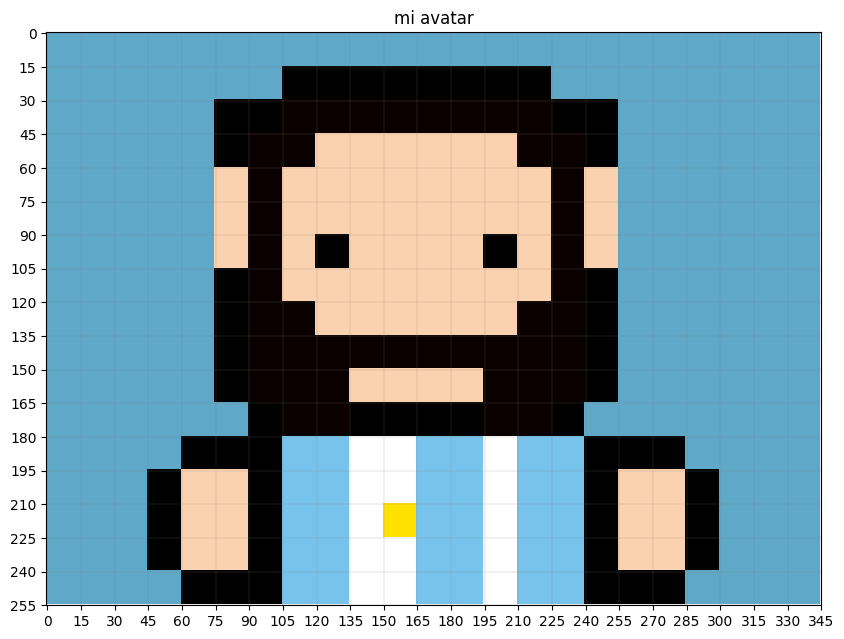

In [63]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- CONFIGURACIÓN DE RUTAS ---
# Mantenemos las rutas de tu proyecto en Univalle
carpeta_base = 'clases/img/'
carpeta_ejercicio = os.path.join(carpeta_base, 'img_AVATAR')

if not os.path.exists(carpeta_ejercicio):
    os.makedirs(carpeta_ejercicio)

# --- PARÁMETROS DEL DISEÑO ---
tamano_casilla =  15 # Cada "píxel" será un cuadrado de 15x15 píxeles reales


# Mismo diseño lógico, forma exactamente igual a la referencia
diseno = [
    ".......................",
    ".......********........",
    ".....**CCCCCCCC**......",
    ".....*CCPPPPPPCC*......",
    ".....PCPPPPPPPPCP......",
    ".....PCPPPPPPPPCP......",
    ".....PCP*PPPP*PCP......",
    ".....*CPPPPPPPPC*......",
    ".....*CCPPPPPPCC*......",
    ".....*CCCCCCCCCC*......",
    ".....*CCCPPPPCCC*......",
    "......*CC****CC*.......",
    "....***AABBAABAA***....",
    "...*PP*AABBAABAA*PP*...",
    "...*PP*AABDAABAA*PP*...",
    "...*PP*AABBAABAA*PP*...",
    "....***AABBAABAA***....",

]

# MAPA DE COLORES (RGB)
# Ajustados para que coincidan perfectamente con la imagen de referencia limpia
mapa_colores = {
    ".": [95, 168, 200], # Blanco puro fondo
    "*": [0, 0, 0],       # Negro puro (bordes y ojos)
    "C": [10, 0, 0],    # Café (Cabello y barba)
    "P": [250, 210, 175], # Piel
    "B": [255, 255, 255], # Blanco camiseta
    "A": [120, 195, 235], # Celeste Argentina
    "D": [255, 225, 0],   # Dorado escudo
    "G": [90, 90, 100],   # Gris oscuro pantalón
    "Z": [240, 240, 240]  # Blanco zapatos
}

# Dimensiones
numero_filas = len(diseno)
numero_columnas = len(diseno[0])
alto_imagen = numero_filas * tamano_casilla
ancho_imagen = numero_columnas * tamano_casilla

# Crear lienzo
imagen = np.zeros((alto_imagen, ancho_imagen, 3), dtype=np.uint8)

# --- CONSTRUCCIÓN DE LA IMAGEN ---
# (Mismo proceso de llenado de bloques)
for fila in range(numero_filas):
    for columna in range(numero_columnas):
        simbolo = diseno[fila][columna]
        color = mapa_colores[simbolo]

        inicio_fila = fila * tamano_casilla
        fin_fila = inicio_fila + tamano_casilla
        inicio_columna = columna * tamano_casilla
        fin_columna = inicio_columna + tamano_casilla

        imagen[inicio_fila:fin_fila, inicio_columna:fin_columna] = color

# --- GUARDADO Y VISUALIZACIÓN MEJORADA ---
ruta_guardado = os.path.join(carpeta_ejercicio, "avatar.png")
# plt.imsave guarda la matriz uint8 directamente sin suavizado
plt.imsave(ruta_guardado, imagen)

# Ajuste del tamaño de visualización para que no se amontone
plt.figure(figsize=(10, 10))

# --- CAMBIO CRUCIAL AQUÍ ---
# interpolation='nearest' asegura que los bordes de los bloques sean nítidos
plt.imshow(imagen, interpolation='nearest')

plt.title("mi avatar")
plt.axis("on") # Dejamos los ejes para referencia de la cuadrícula

# Ajustamos las marcas para que coincidan con las casillas lógicas
plt.xticks(np.arange(0, ancho_imagen + 1, tamano_casilla))
plt.yticks(np.arange(0, alto_imagen + 1, tamano_casilla))

# Ajuste de rejilla para que sea muy suave pero visible, como en el cuaderno
plt.grid(color='gray', linestyle='-', linewidth=0.3, alpha=0.5)

plt.show()



filtros 

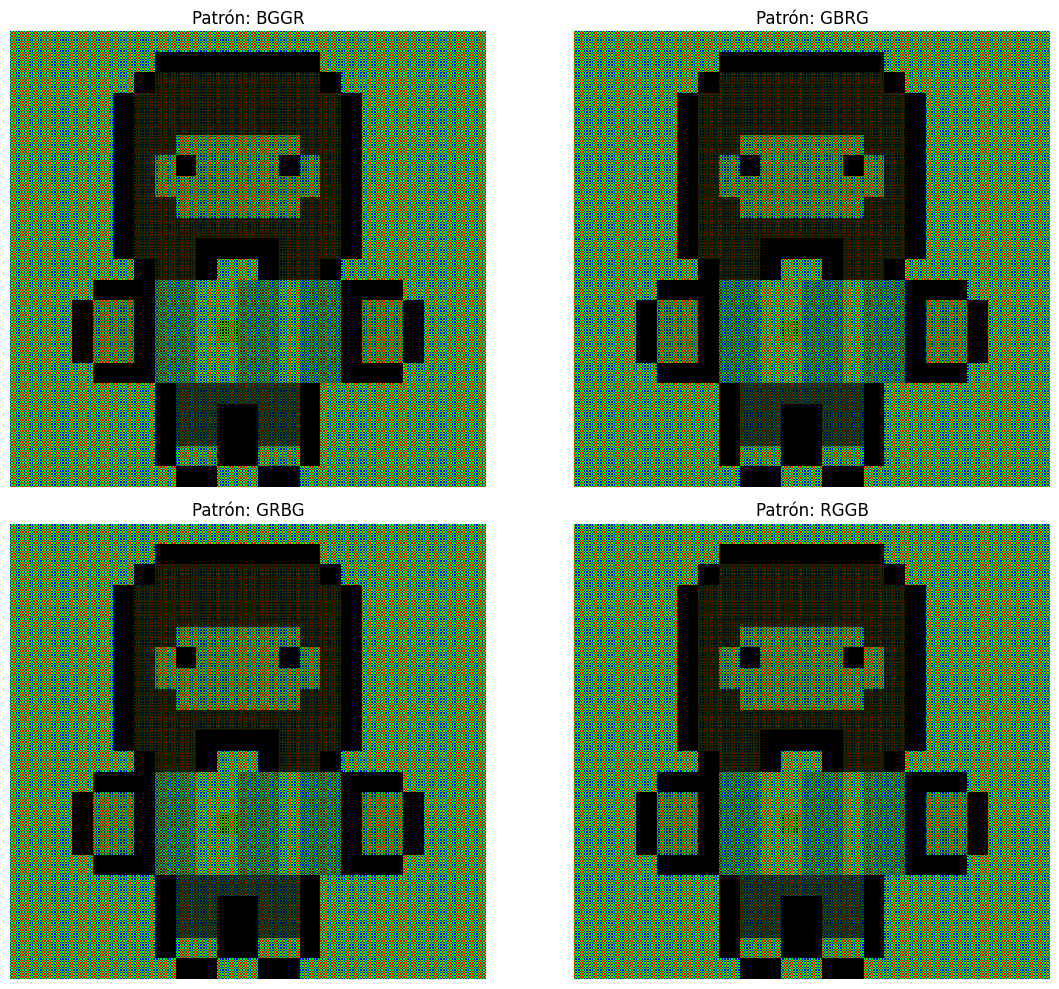

✅ ¡Hecho! Resultados en: clases/img/img_ejercicio_bayer


In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- 1. CONFIGURACIÓN DE RUTAS ---
carpeta_base = 'clases/img/'
carpeta_messi = os.path.join(carpeta_base, 'img_ejercicio_messi')
nombre_archivo = 'messi_pixel_art_limpio.png'
ruta_entrada = os.path.join(carpeta_messi, nombre_archivo)

carpeta_salida = os.path.join(carpeta_base, 'img_ejercicio_bayer')

if not os.path.exists(carpeta_salida):
    os.makedirs(carpeta_salida)

# --- 2. FUNCIONES DE PROCESAMIENTO ---
def separar_canales(imagen):
    return imagen[:, :, 0], imagen[:, :, 1], imagen[:, :, 2]

def reconstruir_rgb(rojo, verde, azul):
    return np.stack((rojo, verde, azul), axis=2)

def aplicar_patron_bayer(rojo, verde, azul, patron):
    alto, ancho = rojo.shape
    mosaico = np.zeros((alto, ancho), dtype=np.uint8)

    # Simulación de captura de sensor
    if patron == "BGGR":
        mosaico[0::2, 0::2] = azul[0::2, 0::2]
        mosaico[0::2, 1::2] = verde[0::2, 1::2]
        mosaico[1::2, 0::2] = verde[1::2, 0::2]
        mosaico[1::2, 1::2] = rojo[1::2, 1::2]
    elif patron == "GBRG":
        mosaico[0::2, 0::2] = verde[0::2, 0::2]
        mosaico[0::2, 1::2] = azul[0::2, 1::2]
        mosaico[1::2, 0::2] = rojo[1::2, 0::2]
        mosaico[1::2, 1::2] = verde[1::2, 1::2]
    elif patron == "GRBG":
        mosaico[0::2, 0::2] = verde[0::2, 0::2]
        mosaico[0::2, 1::2] = rojo[0::2, 1::2]
        mosaico[1::2, 0::2] = azul[1::2, 0::2]
        mosaico[1::2, 1::2] = verde[1::2, 1::2]
    elif patron == "RGGB":
        mosaico[0::2, 0::2] = rojo[0::2, 0::2]
        mosaico[0::2, 1::2] = verde[0::2, 1::2]
        mosaico[1::2, 0::2] = verde[1::2, 0::2]
        mosaico[1::2, 1::2] = azul[1::2, 1::2]

    # Reconstrucción de canales
    r_res = np.zeros_like(rojo); g_res = np.zeros_like(verde); b_res = np.zeros_like(azul)

    if patron == "BGGR":
        b_res[0::2, 0::2] = mosaico[0::2, 0::2]; g_res[0::2, 1::2] = mosaico[0::2, 1::2]
        g_res[1::2, 0::2] = mosaico[1::2, 0::2]; r_res[1::2, 1::2] = mosaico[1::2, 1::2]
    elif patron == "GBRG":
        g_res[0::2, 0::2] = mosaico[0::2, 0::2]; b_res[0::2, 1::2] = mosaico[0::2, 1::2]
        r_res[1::2, 0::2] = mosaico[1::2, 0::2]; g_res[1::2, 1::2] = mosaico[1::2, 1::2]
    elif patron == "GRBG":
        g_res[0::2, 0::2] = mosaico[0::2, 0::2]; r_res[0::2, 1::2] = mosaico[0::2, 1::2]
        b_res[1::2, 0::2] = mosaico[1::2, 0::2]; g_res[1::2, 1::2] = mosaico[1::2, 1::2]
    elif patron == "RGGB":
        r_res[0::2, 0::2] = mosaico[0::2, 0::2]; g_res[0::2, 1::2] = mosaico[0::2, 1::2]
        g_res[1::2, 0::2] = mosaico[1::2, 0::2]; b_res[1::2, 1::2] = mosaico[1::2, 1::2]

    return reconstruir_rgb(r_res, g_res, b_res)

# --- 3. EJECUCIÓN ---
imagen_bgr = cv2.imread(ruta_entrada)

if imagen_bgr is None:
    print(f"❌ Error: No se encontró en {ruta_entrada}")
else:
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    rojo, verde, azul = separar_canales(imagen_rgb)
    
    patrones = ["BGGR", "GBRG", "GRBG", "RGGB"]
    plt.figure(figsize=(12, 10))
    
    for i, patron in enumerate(patrones):
        reconstruida = aplicar_patron_bayer(rojo, verde, azul, patron)
        
        # --- CORRECCIÓN CLAVE ---
        # imsave NO lleva interpolation. Se guarda tal cual es la matriz.
        ruta_save = os.path.join(carpeta_salida, f"messi_bayer_{patron}.png")
        plt.imsave(ruta_save, reconstruida)
        
        plt.subplot(2, 2, i + 1)
        # imshow SÍ lleva interpolation para que se vea bien en pantalla.
        plt.imshow(reconstruida, interpolation='nearest')
        plt.title(f"Patrón: {patron}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()
    print(f"✅ ¡Hecho! Resultados en: {carpeta_salida}")